In [1]:
import os
import sys
import os.path as osp
os.environ["OMP_NUM_THREADS"] = "1"

script_dir = os.getcwd()
workroot_dir = osp.abspath(osp.join(script_dir, "../.."))
os.chdir(workroot_dir)

source_dir = f"{workroot_dir}/sources"
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

if script_dir not in sys.path:
    sys.path.insert(0, script_dir)

os.getcwd()

'/workspace/data2/VSCODE/MOTION/FBMODULES/FBV2'

In [2]:
import gymnasium
from packaging.version import Version
from gymnasium.wrappers import FlattenObservation, TransformObservation
import torch
import math
import mediapy as media
import h5py
import numpy as np

from humenv import make_humenv
from humenv.env import make_from_name
from humenv import rewards as humenv_rewards

from base import agents as base_agents

In [3]:
# resume_path = "/workspace/data2/VSCODE/MOTION/FBMODULES/FBV2/logs/humenv_cprfb_agent/run_2025_11_13_22_08_29/checkpoints/model_59999"
resume_path = "/workspace/data2/VSCODE/MOTION/FBMODULES/FBV2/logs/humenv_cprfb_agent/run_2025_11_15_11_58_54/checkpoints/model_38000"

In [4]:
device = "cpu"

agent = base_agents.AgentProxy.resume_from_dir(resume_path, device = device)
#agent.model.eval()
#calcute = agent.model.calcute

/opt/Miniforge3/envs/SIM45PY310/lib/python3.10/site-packages/wandb/sdk/internal/internal_api.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
2025-11-16 11:07:16.523 | INFO     | base.agents:_resume:126 - resume optimizers: /workspace/data2/VSCODE/MOTION/FBMODULES/FBV2/logs/humenv_cprfb_agent/run_2025_11_15_11_58_54/checkpoints/model_38000/optimizers.pth
2025-11-16 11:07:16.557 | INFO     | base.agents:_resume:132 - resume model: /workspace/data2/VSCODE/MOTION/FBMODULES/FBV2/logs/humenv_cprfb_agent/run_2025_11_15_11_58_54/checkpoints/model_38000/model.safetensors


In [5]:
print(agent.model.forward_map.training)
print(agent.model.backward_map.training)
print(agent.model.actor.training)
print(agent.model.critic.training)
print(agent.model.discriminator.training)
print(agent.model.target_net_forward_map.training)
print(agent.model.target_net_backward_map.training)
print(agent.model.target_net_critic.training)

True
True
True
True
True
True
True
True


In [6]:
agent.model.eval()
calcute = agent.model.calcute

In [7]:
if Version("0.26") <= Version(gymnasium.__version__) < Version("1.0"):
    transform_obs_wrapper = lambda env: TransformObservation(
            env, lambda obs: torch.tensor(obs.reshape(1, -1), dtype=torch.float32, device=device)
        )
else:
    transform_obs_wrapper = lambda env: TransformObservation(
            env, lambda obs: torch.tensor(obs.reshape(1, -1), dtype=torch.float32, device=device), env.observation_space
        )

env, _ = make_humenv(
    num_envs=1,
    wrappers=[
        FlattenObservation,
        transform_obs_wrapper,
    ],
    state_init="Default",
)

In [15]:

z = calcute.sample_z(1)
print(f"embedding size {z.shape}")
print(f"z norm: {torch.norm(z)}")
print(f"z norm / sqrt(d): {torch.norm(z) / math.sqrt(z.shape[-1])}")
observation, _ = env.reset()
frames = [env.render()]
for i in range(180):
    action = calcute.act_inference(state = observation, z_policy = z)
    observation, reward, terminated, truncated, info = env.step(action.detach().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=30)

embedding size torch.Size([1, 256])
z norm: 16.0
z norm / sqrt(d): 1.0


This browser does not support the video tag.


In [12]:
def Qfunction(state, action, z_reward, z_policy):
    F = calcute.forward_representation(state=state, z_policy=z_policy.repeat(state.shape[0],1), action=action) # num_parallel x num_samples x z_dim
    Q = F @ z_reward.ravel()
    return Q.mean(axis=0)

z_reward = calcute.sample_z(1)
z_policy = calcute.sample_z(1)
state = torch.rand((10, env.observation_space.shape[0]), device=calcute.config.device, dtype=torch.float32)
action = torch.rand((10, env.action_space.shape[0]), device=calcute.config.device, dtype=torch.float32)*2 - 1
Q = Qfunction(state, action, z_reward, z_policy)
print(Q)

tensor([179.1091, 194.6570, 241.6080, 111.5227, 340.5245, 183.7274, 176.9644,
        216.7276, 216.5322, 178.0413], grad_fn=<MeanBackward1>)


In [13]:
buffer_path = "/workspace/data2/VSCODE/MOTION/MATA/models/metamotivo-S-1/data/buffer_inference_500000.hdf5"

In [17]:
from base_envs import buffers
from cpr.buffers.configs import DictBufferConfig

In [18]:
hf = h5py.File(buffer_path, "r")
print(hf.keys())
data = {}
for k, v in hf.items():
    print(f"{k:20s}: {v.shape}")
    data[k] = v[:]

config = DictBufferConfig(
    capacity=data["qpos"].shape[0],
    device="cpu"
)
buffer = buffers.BufferProxy(config)
buffer.extend(data)

del data

<KeysViewHDF5 ['action', 'next_observation', 'next_qpos', 'next_qvel', 'observation', 'qpos', 'qvel']>
action              : (500000, 69)
next_observation    : (500000, 358)
next_qpos           : (500000, 76)
next_qvel           : (500000, 75)
observation         : (500000, 358)
qpos                : (500000, 76)
qvel                : (500000, 75)


In [19]:
batch = buffer.sample(5)
for k, v in batch.items():
    print(f"{k:20s}: {v.shape}")

action              : torch.Size([5, 69])
next_observation    : torch.Size([5, 358])
next_qpos           : torch.Size([5, 76])
next_qvel           : torch.Size([5, 75])
observation         : torch.Size([5, 358])
qpos                : torch.Size([5, 76])
qvel                : torch.Size([5, 75])


In [20]:
reward_fn = humenv_rewards.LocomotionReward(move_speed=2.0) # move ahead with speed 2
# humenv provides also a name-base reward initialization. We could
# get the same reward function in this way
reward_fn = make_from_name("move-ego-0-2")
print(reward_fn)

LocomotionReward(move_speed=2.0, stand_height=1.4, move_angle=0.0, egocentric_target=True, low_height=0.6, stay_low=False)


In [21]:
N = 100_000
batch = buffer.sample(N)
rewards = []
for i in range(N):
    rewards.append(
        reward_fn(
            env.unwrapped.model,
            qpos=batch["next_qpos"][i],
            qvel=batch["next_qvel"][i],
            ctrl=batch["action"][i])
    )
rewards = np.stack(rewards).reshape(-1,1)
print(rewards.ravel())

[5.97550318e-06 2.64552475e-01 1.07475612e-01 ... 2.74209711e-01
 8.13900277e-01 2.65371666e-01]


In [ ]:
z = calcute.reward_wr_inference(
    state=batch["next_observation"],
    reward=torch.tensor(rewards, device=calcute.config.device, dtype=torch.float32)
)
print(z.shape)

observation, _ = env.reset()
frames = [env.render()]
for i in range(120):
    action = calcute.act_inference(state=observation, z_policy = z, mean=True)
    observation, reward, terminated, truncated, info = env.step(action.detach().cpu().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=120)

torch.Size([1, 256])


This browser does not support the video tag.


goal pose


""

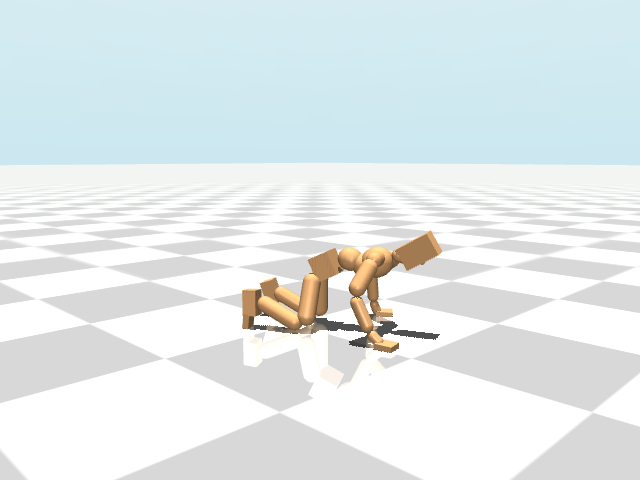

In [10]:
goal_qpos = np.array([0.13769039,-0.20029453,0.42305034,0.21707786,0.94573617,0.23868944
,0.03856998,-1.05566834,-0.12680767,0.11718296,1.89464102,-0.01371153
,-0.07981451,-0.70497424,-0.0478,-0.05700732,-0.05363342,-0.0657329
,0.08163511,-1.06263979,0.09788937,-0.22008936,1.85898192,0.08773695
,0.06200327,-0.3802791,0.07829525,0.06707749,0.14137152,0.08834448
,-0.07649805,0.78328658,0.12580912,-0.01076061,-0.35937259,-0.13176489
,0.07497022,-0.2331914,-0.11682692,0.04782308,-0.13571422,0.22827948
,-0.23456622,-0.12406075,-0.04466465,0.2311667,-0.12232673,-0.25614032
,-0.36237662,0.11197906,-0.08259534,-0.634934,-0.30822742,-0.93798716
,0.08848668,0.4083417,-0.30910404,0.40950143,0.30815359,0.03266103
,1.03959336,-0.19865537,0.25149713,0.3277561,0.16943092,0.69125975
,0.21721349,-0.30871948,0.88890484,-0.08884043,0.38474549,0.30884107
,-0.40933304,0.30889523,-0.29562966,-0.6271498])
env.unwrapped.set_physics(qpos=goal_qpos, qvel=np.zeros(75))
goal_obs = torch.tensor(env.unwrapped.get_obs()["proprio"].reshape(1,-1), device=calcute.config.device, dtype=torch.float32)
print("goal pose")
media.show_image(env.render())

In [11]:
z = calcute.goal_inference(state=goal_obs)


observation, _ = env.reset()
frames = [env.render()]
for i in range(120):
    action = calcute.act_inference(state=observation, z_policy = z, mean=True)
    observation, reward, terminated, truncated, info = env.step(action.detach().cpu().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=30)

This browser does not support the video tag.
